# Plant Stress Risk Modeling With Tuned Boosting Classifiers

This notebook predicts plant health status from soil, nutrient, environmental, and biosensor readings.

## Workflow

- Load the local plant health dataset
- Check target balance and sensor ranges
- Tune LightGBM, CatBoost, and XGBoost with GridSearchCV
- Compare the tuned models with macro F1-score
- Review the strongest model and its feature importance

In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

## Load Data

In [3]:
DATA_PATH = 'data/plant_health_data.csv'

plant_data = pd.read_csv(DATA_PATH)
plant_data.head()

,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


In [4]:
plant_data.shape

(1200, 14)

In [5]:
plant_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               1200 non-null   object 
 1   Plant_ID                1200 non-null   int64  
 2   Soil_Moisture           1200 non-null   float64
 3   Ambient_Temperature     1200 non-null   float64
 4   Soil_Temperature        1200 non-null   float64
 5   Humidity                1200 non-null   float64
 6   Light_Intensity         1200 non-null   float64
 7   Soil_pH                 1200 non-null   float64
 8   Nitrogen_Level          1200 non-null   float64
 9   Phosphorus_Level        1200 non-null   float64
 10  Potassium_Level         1200 non-null   float64
 11  Chlorophyll_Content     1200 non-null   float64
 12  Electrochemical_Signal  1200 non-null   float64
 13  Plant_Health_Status     1200 non-null   object 
dtypes: float64(11), int64(1), object(2)
memo

## Data Check

In [6]:
missing_summary = plant_data.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

Series([], dtype: int64)

In [7]:
target_column = 'Plant_Health_Status'
health_counts = plant_data[target_column].value_counts()
health_counts

Plant_Health_Status
High Stress        500
Moderate Stress    401
Healthy            299
Name: count, dtype: int64

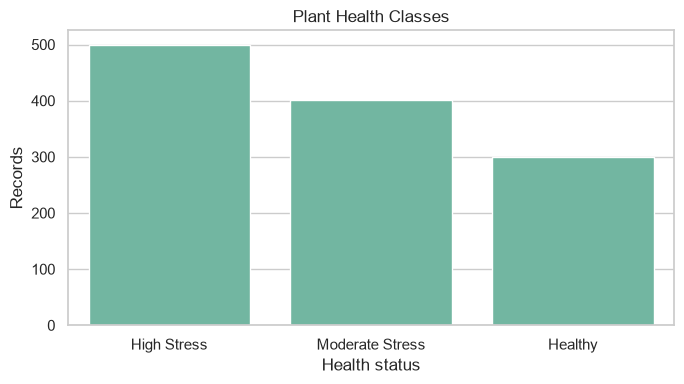

In [8]:
plt.figure(figsize=(7, 4))
sns.barplot(x=health_counts.index, y=health_counts.values)
plt.title('Plant Health Classes')
plt.ylabel('Records')
plt.xlabel('Health status')
plt.tight_layout()
plt.show()

## Modeling Features

In [9]:
model_features = [
    'Soil_Moisture',
    'Ambient_Temperature',
    'Soil_Temperature',
    'Humidity',
    'Light_Intensity',
    'Soil_pH',
    'Nitrogen_Level',
    'Phosphorus_Level',
    'Potassium_Level',
    'Chlorophyll_Content',
    'Electrochemical_Signal',
]

plant_data[model_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Soil_Moisture,1200.0,25.106918,8.677725,10.000724,17.131893,25.168333,32.370231,39.993164
Ambient_Temperature,1200.0,23.999130,3.441561,18.001993,21.101766,23.889044,27.042634,29.990886
Soil_Temperature,1200.0,19.957794,2.932073,15.003710,17.353027,19.911473,22.596851,24.995929
Humidity,1200.0,54.853165,8.784916,40.028758,47.019694,54.692069,62.451053,69.968871
Light_Intensity,1200.0,612.637265,228.318853,200.615482,416.878983,617.240221,811.474690,999.856262
Soil_pH,1200.0,6.524102,0.581755,5.507392,6.026042,6.540524,7.030039,7.497823
Nitrogen_Level,1200.0,30.106751,11.514396,10.003650,20.249774,30.138590,40.184737,49.951136
Phosphorus_Level,1200.0,30.264484,11.466846,10.017690,20.894445,30.019385,40.131459,49.980700
Potassium_Level,1200.0,30.112088,11.668085,10.000606,19.585561,30.495054,40.108296,49.981945
Chlorophyll_Content,1200.0,34.749591,8.766995,20.025511,27.463350,34.433427,42.232637,49.990811


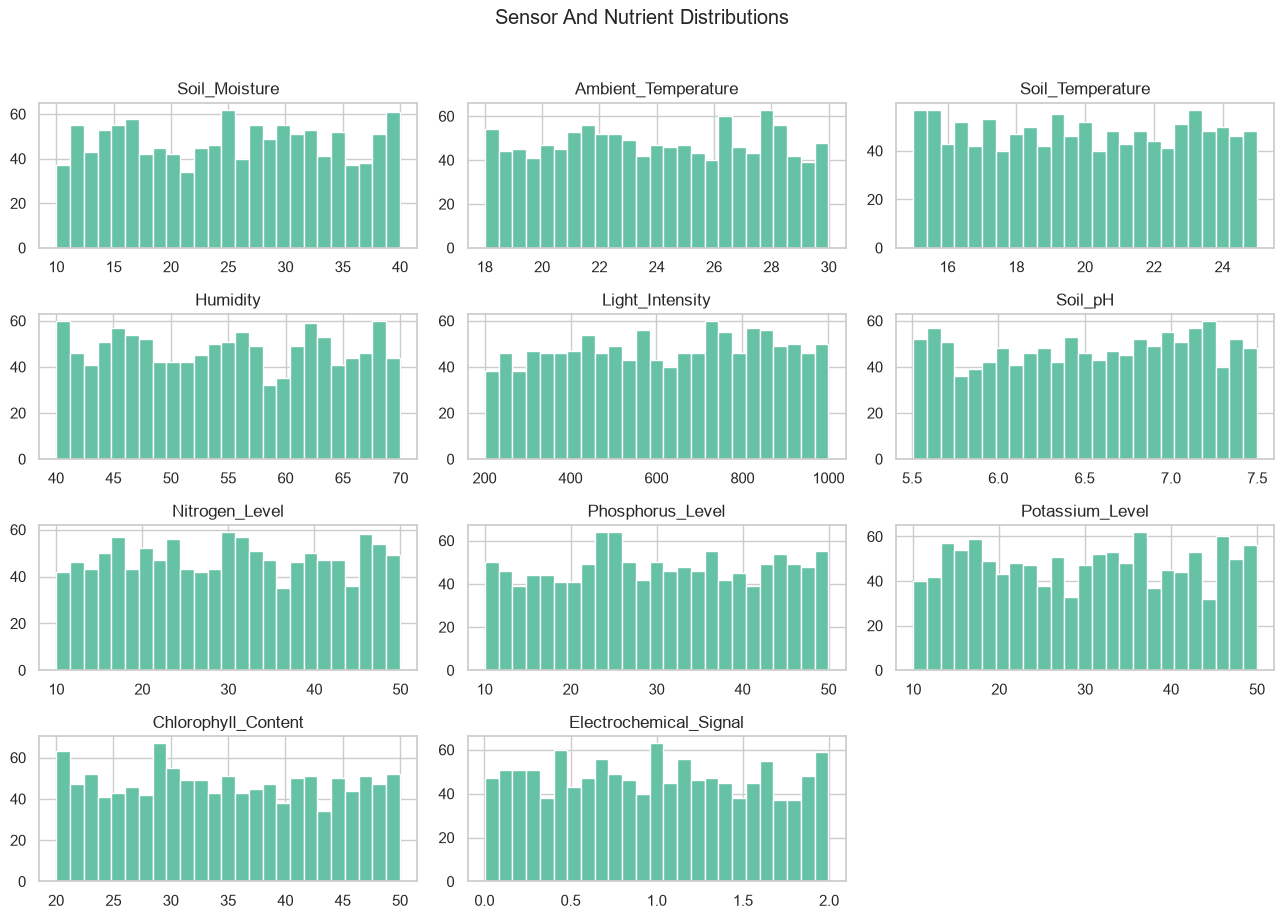

In [10]:
plant_data[model_features].hist(figsize=(13, 9), bins=25)
plt.suptitle('Sensor And Nutrient Distributions', y=1.02)
plt.tight_layout()
plt.show()

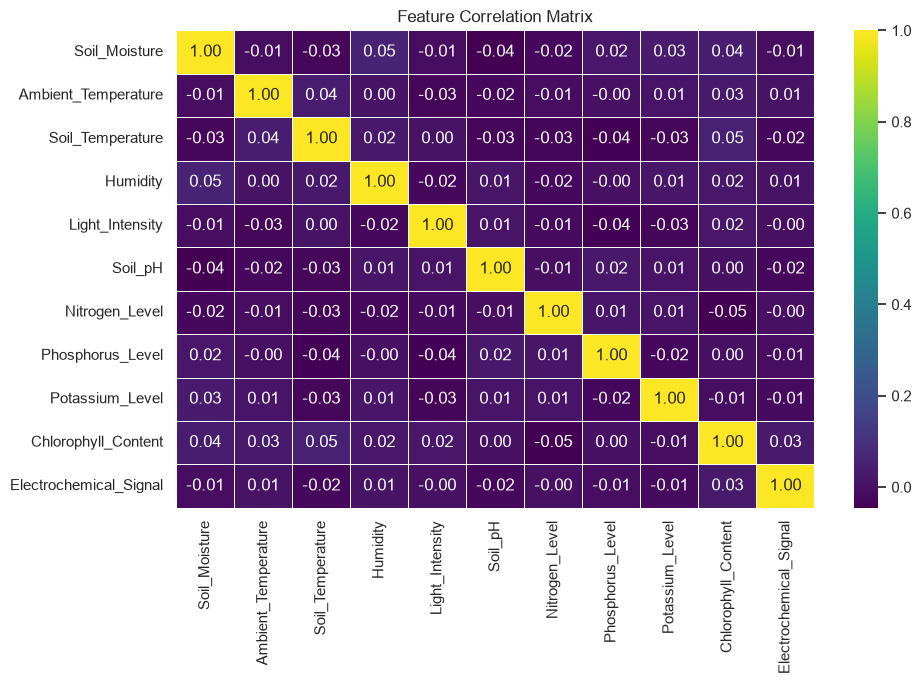

In [11]:
plt.figure(figsize=(10, 7))
sns.heatmap(plant_data[model_features].corr(), cmap='viridis', annot=True, fmt='.2f', linewidths=0.4)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Train-Test Split

In [12]:
label_encoder = LabelEncoder()
encoded_target = label_encoder.fit_transform(plant_data[target_column])

features = plant_data[model_features]

training_features, test_features, training_labels, test_labels = train_test_split(
    features,
    encoded_target,
    test_size=0.20,
    random_state=42,
    stratify=encoded_target,
)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
class_mapping

{'Healthy': np.int64(0),
 'High Stress': np.int64(1),
 'Moderate Stress': np.int64(2)}

## Grid Search Setup

In [13]:
model_search_spaces = {
    'LightGBM': {
        'estimator': LGBMClassifier(
            objective='multiclass',
            random_state=42,
            verbosity=-1,
            n_jobs=1,
        ),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.10],
            'num_leaves': [15, 31],
            'max_depth': [-1, 5],
        },
    },
    'CatBoost': {
        'estimator': CatBoostClassifier(
            loss_function='MultiClass',
            random_seed=42,
            verbose=False,
            allow_writing_files=False,
            thread_count=1,
        ),
        'params': {
            'iterations': [150, 250],
            'learning_rate': [0.05, 0.10],
            'depth': [4, 6],
        },
    },
    'XGBoost': {
        'estimator': XGBClassifier(
            objective='multi:softprob',
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=1,
        ),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.10],
            'max_depth': [3, 5],
            'subsample': [0.85, 1.00],
        },
    },
}

## Tune And Compare Models

In [14]:
search_results = []
best_estimators = {}

for model_name, search_config in model_search_spaces.items():
    grid_search = GridSearchCV(
        estimator=search_config['estimator'],
        param_grid=search_config['params'],
        scoring='f1_macro',
        cv=3,
        n_jobs=1,
        refit=True,
    )

    grid_search.fit(training_features, training_labels)
    predictions = grid_search.predict(test_features)

    best_estimators[model_name] = grid_search.best_estimator_
    search_results.append(
        {
            'model': model_name,
            'best_params': grid_search.best_params_,
            'cv_macro_f1': grid_search.best_score_,
            'accuracy': accuracy_score(test_labels, predictions),
            'precision_macro': precision_score(test_labels, predictions, average='macro'),
            'recall_macro': recall_score(test_labels, predictions, average='macro'),
            'f1_macro': f1_score(test_labels, predictions, average='macro'),
        }
    )

score_table = pd.DataFrame(search_results).sort_values(
    by=['f1_macro', 'accuracy'],
    ascending=False,
).reset_index(drop=True)

score_table

,model,best_params,cv_macro_f1,accuracy,precision_macro,recall_macro,f1_macro
0,LightGBM,"{'learning_rate': 0.05, 'max_depth': -1, 'n_es...",0.992326,1.000000,1.000000,1.000000,1.000000
1,CatBoost,"{'depth': 4, 'iterations': 150, 'learning_rate...",0.997195,0.995833,0.995885,0.996667,0.996255
2,XGBoost,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.992607,0.995833,0.994536,0.995833,0.995149


In [15]:
score_table[['model', 'best_params']]

,model,best_params
0,LightGBM,"{'learning_rate': 0.05, 'max_depth': -1, 'n_es..."
1,CatBoost,"{'depth': 4, 'iterations': 150, 'learning_rate..."
2,XGBoost,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est..."


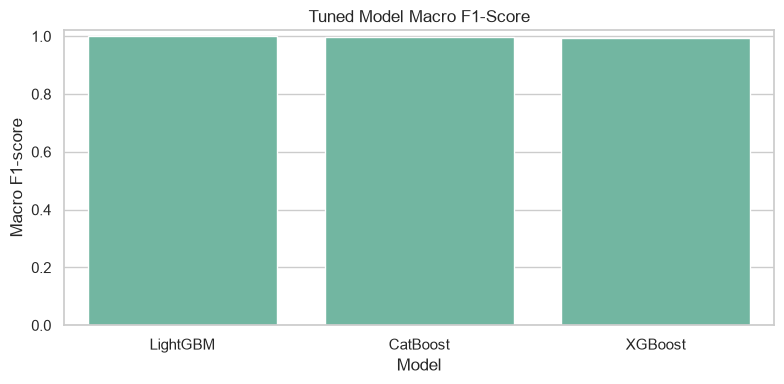

In [16]:
plt.figure(figsize=(8, 4))
sns.barplot(data=score_table, x='model', y='f1_macro')
plt.title('Tuned Model Macro F1-Score')
plt.ylim(0, 1.02)
plt.xlabel('Model')
plt.ylabel('Macro F1-score')
plt.tight_layout()
plt.show()

## Selected Model

In [17]:
best_model_name = score_table.loc[0, 'model']
best_plant_stress_model = best_estimators[best_model_name]
best_predictions = best_plant_stress_model.predict(test_features)

print(f'Best model: {best_model_name}')
print(classification_report(test_labels, best_predictions, target_names=label_encoder.classes_))

Best model: LightGBM
                 precision    recall  f1-score   support

        Healthy       1.00      1.00      1.00        60
    High Stress       1.00      1.00      1.00       100
Moderate Stress       1.00      1.00      1.00        80

       accuracy                           1.00       240
      macro avg       1.00      1.00      1.00       240
   weighted avg       1.00      1.00      1.00       240



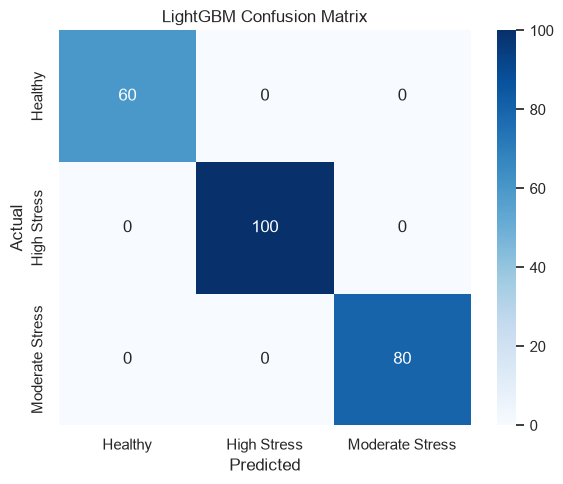

In [18]:
confusion = confusion_matrix(test_labels, best_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title(f'{best_model_name} Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Feature Importance

In [19]:
importance_values = best_plant_stress_model.feature_importances_

feature_importance = pd.DataFrame(
    {
        'feature': model_features,
        'importance': importance_values,
    }
).sort_values('importance', ascending=False)

feature_importance

,feature,importance
0,Soil_Moisture,1509
6,Nitrogen_Level,819
1,Ambient_Temperature,498
3,Humidity,429
8,Potassium_Level,286
2,Soil_Temperature,275
7,Phosphorus_Level,270
5,Soil_pH,46
9,Chlorophyll_Content,23
4,Light_Intensity,10


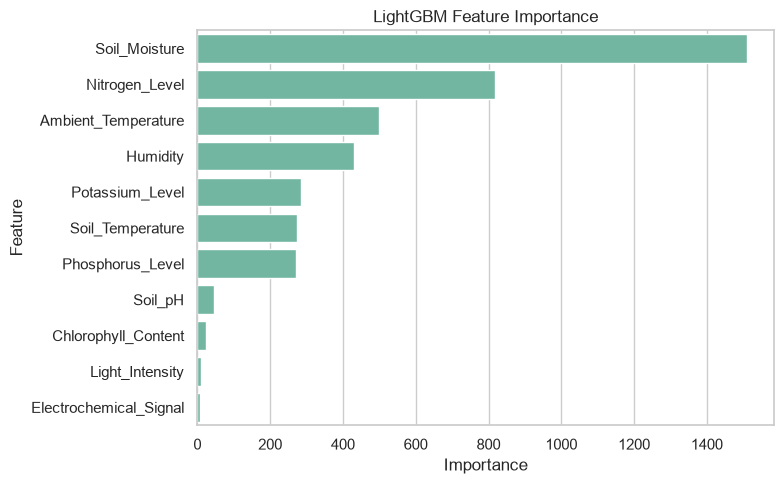

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title(f'{best_model_name} Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Sample Prediction

In [21]:
example_reading = test_features.iloc[[0]]
encoded_prediction = best_plant_stress_model.predict(example_reading)
predicted_status = label_encoder.inverse_transform(encoded_prediction.astype(int).ravel())

example_reading.assign(predicted_health_status=predicted_status[0])

,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,predicted_health_status
1003,35.276253,19.173263,24.108578,41.665161,957.098672,7.141164,25.095414,36.213768,10.842075,24.271737,0.049921,Healthy


## Takeaway

LightGBM produced the strongest test-set result in this run. The tuned boosting models all performed well, which fits the structured sensor data and the clear class pattern in the dataset.